In [59]:
import pandas as pd

survey = pd.read_csv("./datasets/wages.csv")
survey.drop(labels=["del"], axis=1, inplace=True)
survey["race"] = survey["ethnicity"].copy()
survey.drop(labels=["ethnicity"], axis=1, inplace=True)
survey.describe(include="all")

,wage,education,experience,age,region,gender,occupation,sector,union,married,race
count,534.000000,534.000000,534.000000,534.000000,534,534,534,534,534,534,534
unique,NaN,NaN,NaN,NaN,2,2,6,3,2,2,3
top,NaN,NaN,NaN,NaN,other,male,worker,other,no,yes,cauc
freq,NaN,NaN,NaN,NaN,378,289,156,411,438,350,440
mean,9.024064,13.018727,17.822097,36.833333,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,5.139097,2.615373,12.379710,11.726573,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,2.000000,0.000000,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,5.250000,12.000000,8.000000,28.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,7.780000,12.000000,15.000000,35.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,11.250000,15.000000,26.000000,44.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [60]:
survey.head()

,wage,education,experience,age,region,gender,occupation,sector,union,married,race
0,5.10,8,21,35,other,female,worker,manufacturing,no,yes,hispanic
1,4.95,9,42,57,other,female,worker,manufacturing,no,yes,cauc
2,6.67,12,1,19,other,male,worker,manufacturing,no,no,cauc
3,4.00,12,4,22,other,male,worker,other,no,no,cauc
4,7.50,12,17,35,other,male,worker,other,no,yes,cauc


In [61]:
X = survey[survey.columns[1:]]
y = survey["wage"]

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

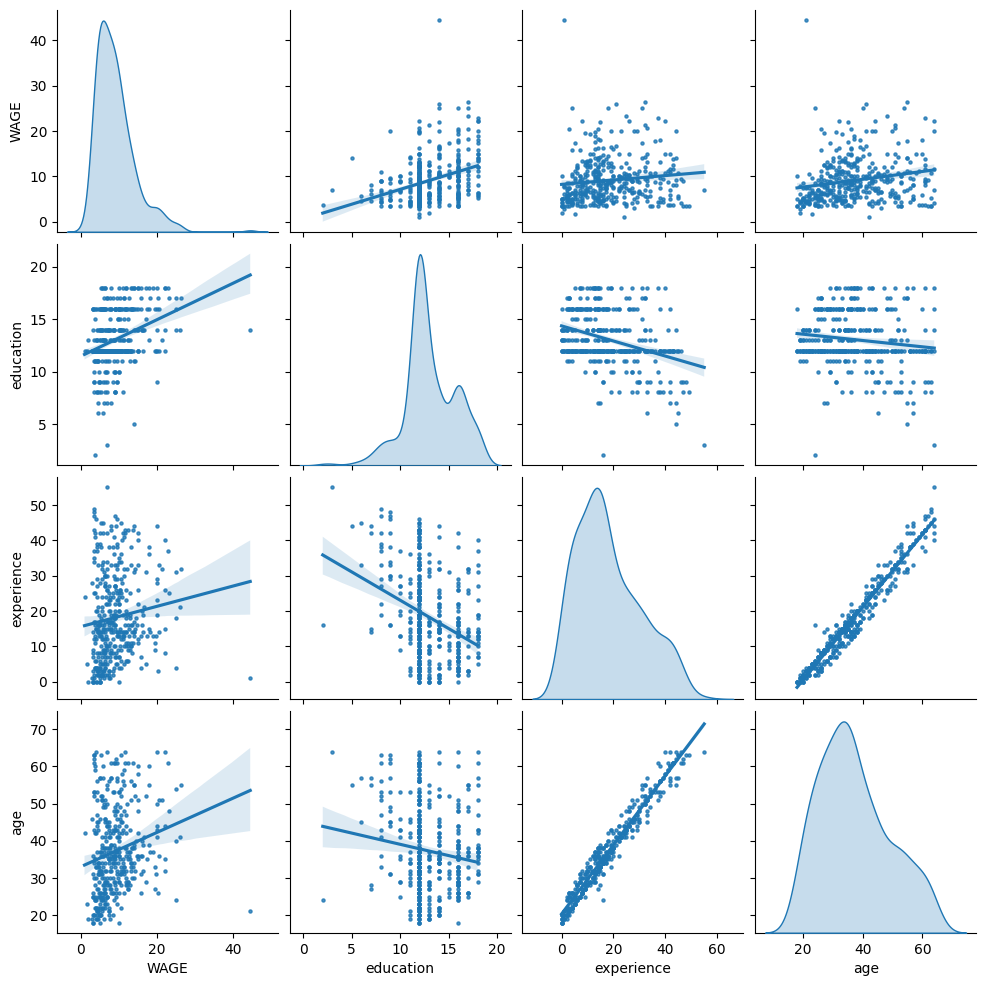

In [63]:
import seaborn as sns

train_dataset = X_train.copy()
train_dataset.insert(0, "WAGE", y_train)
_ = sns.pairplot(
    train_dataset, kind="reg", diag_kind="kde", plot_kws={"scatter_kws": {"s": 5}}
)

In [64]:
survey.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 534 entries, 0 to 533
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   wage        534 non-null    float64
 1   education   534 non-null    int64  
 2   experience  534 non-null    int64  
 3   age         534 non-null    int64  
 4   region      534 non-null    object 
 5   gender      534 non-null    object 
 6   occupation  534 non-null    object 
 7   sector      534 non-null    object 
 8   union       534 non-null    object 
 9   married     534 non-null    object 
 10  race        534 non-null    object 
dtypes: float64(1), int64(3), object(7)
memory usage: 46.0+ KB


In [65]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

categorical_columns = [
    "RACE",
    "OCCUPATION",
    "SECTOR",
    "MARRIED",
    "UNION",
    "GENDER",
    "REGION",
]
categorical_columns = [x.lower() for x in categorical_columns]
numerical_columns = ["EDUCATION", "EXPERIENCE", "AGE"]
numerical_columns = [x.lower() for x in numerical_columns]

preprocessor = make_column_transformer(
    (OneHotEncoder(drop="if_binary"), categorical_columns),
    remainder="passthrough",
    verbose_feature_names_out=False,  # avoid to prepend the preprocessor names
)

We use a ridge regressor with a very small regularization to model the logarithm of the WAGE.

In [66]:
import numpy as np
import scipy as sp
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline

model = make_pipeline(
    preprocessor,
    TransformedTargetRegressor(
        regressor=Ridge(alpha=1e-10), func=np.log10, inverse_func=sp.special.exp10
    ),
)
model

,steps,"[('columntransformer', ...), ('transformedtargetregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehotencoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [67]:
model.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('transformedtargetregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehotencoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


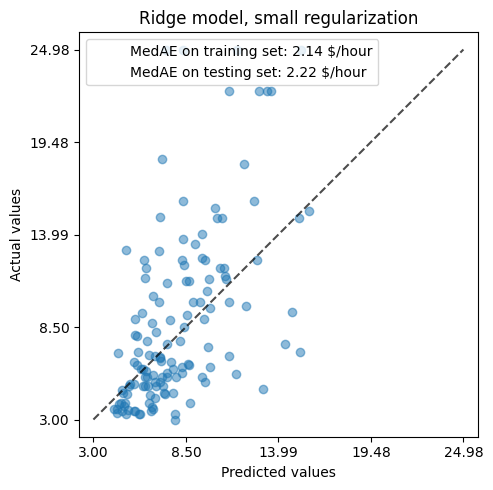

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import PredictionErrorDisplay, median_absolute_error

mae_train = median_absolute_error(y_train, model.predict(X_train))
y_pred = model.predict(X_test)
mae_test = median_absolute_error(y_test, y_pred)
scores = {
    "MedAE on training set": f"{mae_train:.2f} $/hour",
    "MedAE on testing set": f"{mae_test:.2f} $/hour",
}

_, ax = plt.subplots(figsize=(5, 5))
display = PredictionErrorDisplay.from_predictions(
    y_test, y_pred, kind="actual_vs_predicted", ax=ax, scatter_kwargs={"alpha": 0.5}
)
ax.set_title("Ridge model, small regularization")
for name, score in scores.items():
    ax.plot([], [], " ", label=f"{name}: {score}")
ax.legend(loc="upper left")
plt.tight_layout()

In [70]:
feature_names = model[:-1].get_feature_names_out()

coefs = pd.DataFrame(
    model[-1].regressor_.coef_,
    columns=["Coefficients"],
    index=feature_names,
)

coefs


,Coefficients
race_cauc,0.022503
race_hispanic,-0.013611
race_other,-0.009167
occupation_management,0.090755
occupation_office,0.000272
occupation_sales,-0.046409
occupation_services,-0.090826
occupation_technical,0.072191
occupation_worker,-0.024874
sector_construction,-0.000359


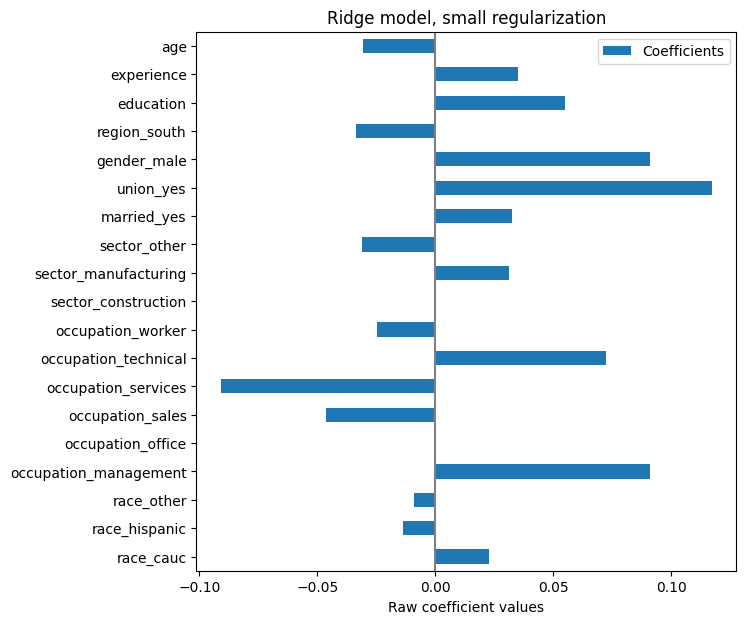

In [71]:
coefs.plot.barh(figsize=(9, 7))
plt.title("Ridge model, small regularization")
plt.axvline(x=0, color=".5")
plt.xlabel("Raw coefficient values")
plt.subplots_adjust(left=0.3)

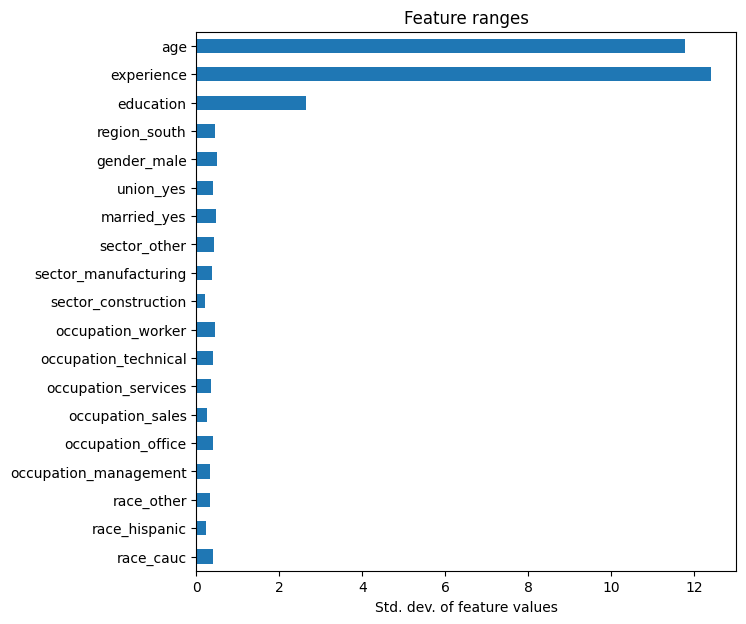

In [72]:
X_train_preprocessed = pd.DataFrame(
    model[:-1].transform(X_train), columns=feature_names
)

X_train_preprocessed.std(axis=0).plot.barh(figsize=(9, 7))
plt.title("Feature ranges")
plt.xlabel("Std. dev. of feature values")
plt.subplots_adjust(left=0.3)


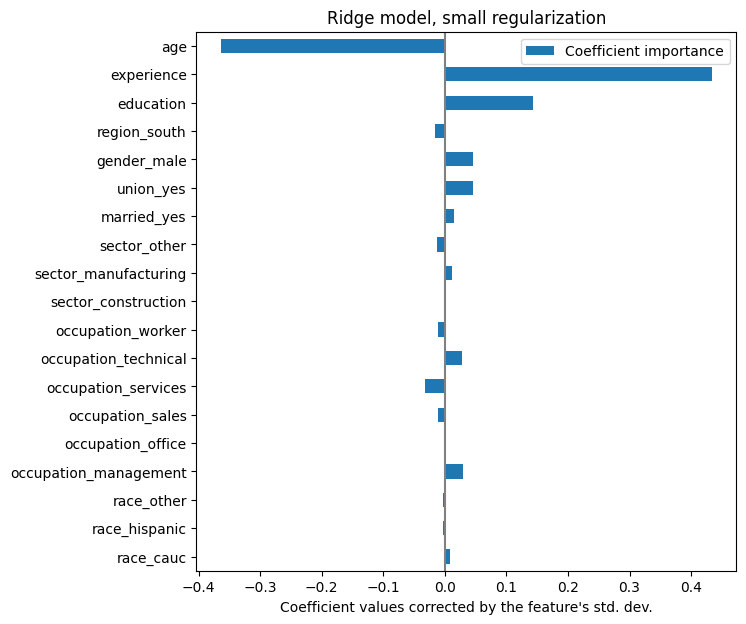

In [73]:
coefs = pd.DataFrame(
    model[-1].regressor_.coef_ * X_train_preprocessed.std(axis=0),
    columns=["Coefficient importance"],
    index=feature_names,
)
coefs.plot(kind="barh", figsize=(9, 7))
plt.xlabel("Coefficient values corrected by the feature's std. dev.")
plt.title("Ridge model, small regularization")
plt.axvline(x=0, color=".5")
plt.subplots_adjust(left=0.3)


In [74]:
from sklearn.model_selection import RepeatedKFold, cross_validate

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=0)
cv_model = cross_validate(
    model,
    X,
    y,
    cv=cv,
    return_estimator=True,
    n_jobs=2,
)

coefs = pd.DataFrame(
    [
        est[-1].regressor_.coef_ * est[:-1].transform(X.iloc[train_idx]).std(axis=0)
        for est, (train_idx, _) in zip(cv_model["estimator"], cv.split(X, y))
    ],
    columns=feature_names,
)


Exception ignored in: <_io.BytesIO object at 0x1222dda30>
Traceback (most recent call last):
  File "/Users/amkhrjee/Developer/stats/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py", line 110, in _get_memory_usage
Exception ignored in: <_io.BytesIO object at 0x10b8b2750>
Traceback (most recent call last):
  File "/Users/amkhrjee/Developer/stats/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py", line 110, in _get_memory_usage
    gc.collect()
BufferError: Existing exports of data: object cannot be re-sized
    gc.collect()
BufferError: Existing exports of data: object cannot be re-sized
Exception ignored in: <_io.BytesIO object at 0x12228f600>
Traceback (most recent call last):
  File "/Users/amkhrjee/Developer/stats/.venv/lib/python3.13/site-packages/pandas/core/generic.py", line 6286, in __finalize__
    for name in set(self._metadata) & set(other._metadata):
BufferError: Existing exports of data: object cannot be re-sized
Excep

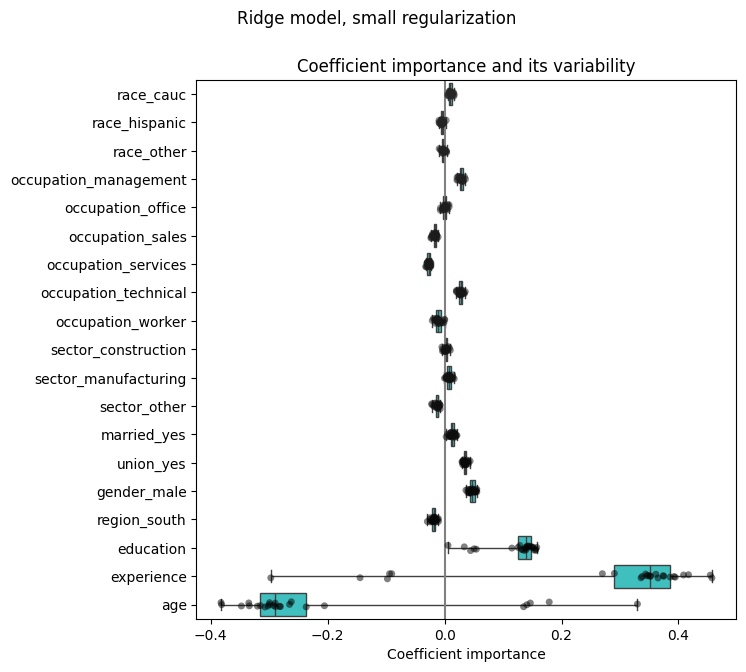

In [75]:
plt.figure(figsize=(9, 7))
sns.stripplot(data=coefs, orient="h", palette="dark:k", alpha=0.5)
sns.boxplot(data=coefs, orient="h", color="cyan", saturation=0.5, whis=10)
plt.axvline(x=0, color=".5")
plt.xlabel("Coefficient importance")
plt.title("Coefficient importance and its variability")
plt.suptitle("Ridge model, small regularization")
plt.subplots_adjust(left=0.3)


In [76]:
column_to_drop = ["age"]

cv_model = cross_validate(
    model,
    X.drop(columns=column_to_drop),
    y,
    cv=cv,
    return_estimator=True,
    n_jobs=2,
)

coefs = pd.DataFrame(
    [
        est[-1].regressor_.coef_
        * est[:-1].transform(X.drop(columns=column_to_drop).iloc[train_idx]).std(axis=0)
        for est, (train_idx, _) in zip(cv_model["estimator"], cv.split(X, y))
    ],
    columns=feature_names[:-1],
)


Exception ignored in: <_io.BytesIO object at 0x10b8e7600>
Traceback (most recent call last):
  File "/Users/amkhrjee/Developer/stats/.venv/lib/python3.13/site-packages/pandas/core/generic.py", line 6342, in __setattr__
    object.__setattr__(self, name, value)
BufferError: Existing exports of data: object cannot be re-sized
Exception ignored in: <_io.BytesIO object at 0x10b937ec0>
Traceback (most recent call last):
  File "/Users/amkhrjee/Developer/stats/.venv/lib/python3.13/site-packages/pandas/core/generic.py", line 6342, in __setattr__
    object.__setattr__(self, name, value)
BufferError: Existing exports of data: object cannot be re-sized
Exception ignored in: <_io.BytesIO object at 0x10a8370b0>
Traceback (most recent call last):
  File "/Users/amkhrjee/Developer/stats/.venv/lib/python3.13/site-packages/pandas/core/generic.py", line 6342, in __setattr__
    object.__setattr__(self, name, value)
BufferError: Existing exports of data: object cannot be re-sized
Exception ignored in: 

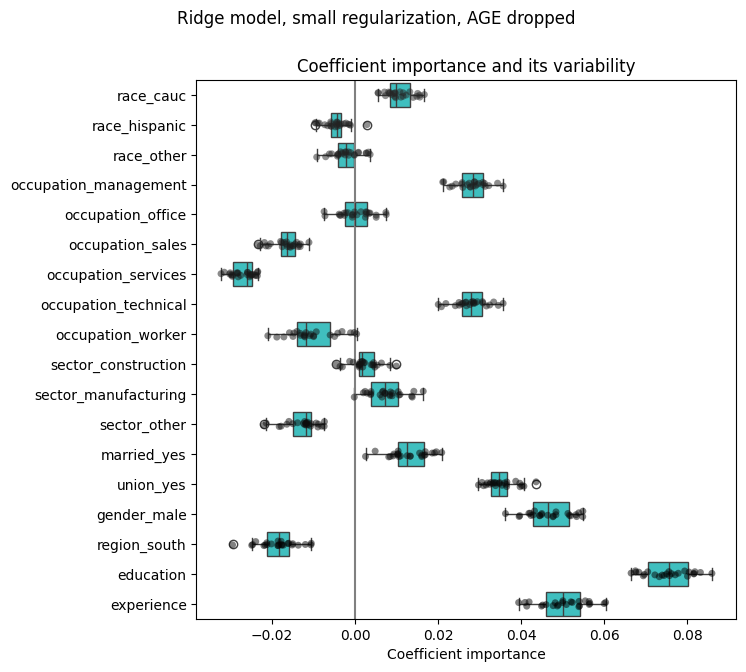

In [77]:
plt.figure(figsize=(9, 7))
sns.stripplot(data=coefs, orient="h", palette="dark:k", alpha=0.5)
sns.boxplot(data=coefs, orient="h", color="cyan", saturation=0.5)
plt.axvline(x=0, color=".5")
plt.title("Coefficient importance and its variability")
plt.xlabel("Coefficient importance")
plt.suptitle("Ridge model, small regularization, AGE dropped")
plt.subplots_adjust(left=0.3)


In [78]:
from sklearn.preprocessing import StandardScaler

preprocessor = make_column_transformer(
    (OneHotEncoder(drop="if_binary"), categorical_columns),
    (StandardScaler(), numerical_columns),
)


In [79]:
model = make_pipeline(
    preprocessor,
    TransformedTargetRegressor(
        regressor=Ridge(alpha=1e-10), func=np.log10, inverse_func=sp.special.exp10
    ),
)
model.fit(X_train, y_train)


,steps,"[('columntransformer', ...), ('transformedtargetregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehotencoder', ...), ('standardscaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


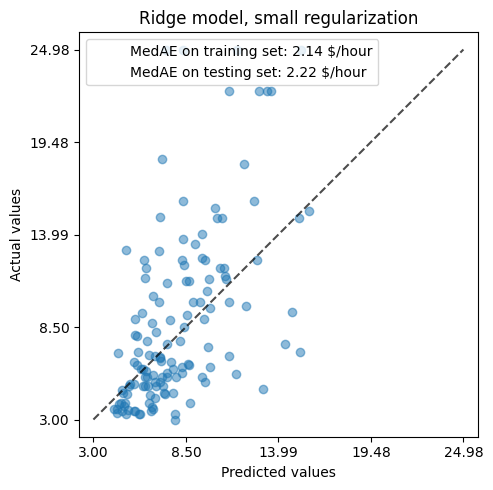

In [80]:
mae_train = median_absolute_error(y_train, model.predict(X_train))
y_pred = model.predict(X_test)
mae_test = median_absolute_error(y_test, y_pred)
scores = {
    "MedAE on training set": f"{mae_train:.2f} $/hour",
    "MedAE on testing set": f"{mae_test:.2f} $/hour",
}

_, ax = plt.subplots(figsize=(5, 5))
display = PredictionErrorDisplay.from_predictions(
    y_test, y_pred, kind="actual_vs_predicted", ax=ax, scatter_kwargs={"alpha": 0.5}
)
ax.set_title("Ridge model, small regularization")
for name, score in scores.items():
    ax.plot([], [], " ", label=f"{name}: {score}")
ax.legend(loc="upper left")
plt.tight_layout()


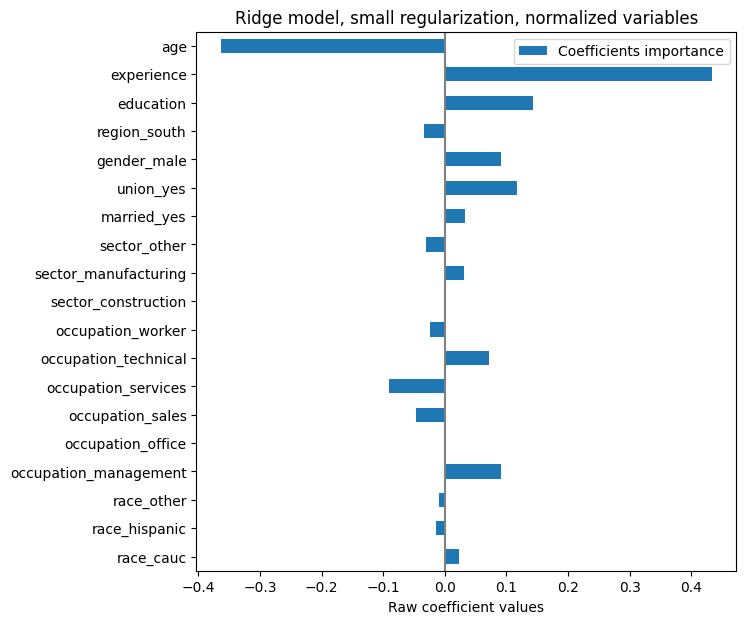

In [81]:
coefs = pd.DataFrame(
    model[-1].regressor_.coef_,
    columns=["Coefficients importance"],
    index=feature_names,
)
coefs.plot.barh(figsize=(9, 7))
plt.title("Ridge model, small regularization, normalized variables")
plt.xlabel("Raw coefficient values")
plt.axvline(x=0, color=".5")
plt.subplots_adjust(left=0.3)


In [82]:
from sklearn.linear_model import RidgeCV

alphas = np.logspace(-10, 10, 21)  # alpha values to be chosen from by cross-validation
model = make_pipeline(
    preprocessor,
    TransformedTargetRegressor(
        regressor=RidgeCV(alphas=alphas),
        func=np.log10,
        inverse_func=sp.special.exp10,
    ),
)
model.fit(X_train, y_train)


,steps,"[('columntransformer', ...), ('transformedtargetregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehotencoder', ...), ('standardscaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [83]:
model[-1].regressor_.alpha_


np.float64(10.0)

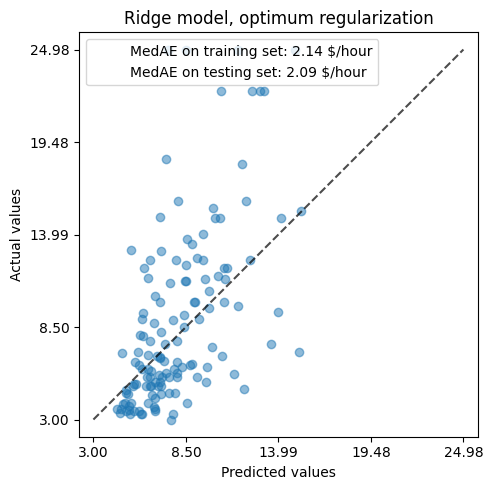

In [84]:
mae_train = median_absolute_error(y_train, model.predict(X_train))
y_pred = model.predict(X_test)
mae_test = median_absolute_error(y_test, y_pred)
scores = {
    "MedAE on training set": f"{mae_train:.2f} $/hour",
    "MedAE on testing set": f"{mae_test:.2f} $/hour",
}

_, ax = plt.subplots(figsize=(5, 5))
display = PredictionErrorDisplay.from_predictions(
    y_test, y_pred, kind="actual_vs_predicted", ax=ax, scatter_kwargs={"alpha": 0.5}
)
ax.set_title("Ridge model, optimum regularization")
for name, score in scores.items():
    ax.plot([], [], " ", label=f"{name}: {score}")
ax.legend(loc="upper left")
plt.tight_layout()


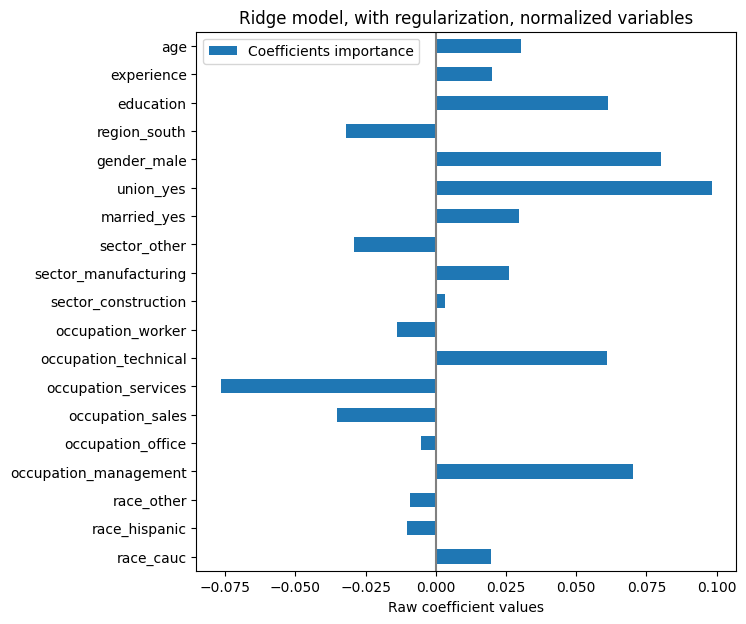

Exception ignored in: <_io.BytesIO object at 0x12210c4a0>
BufferError: Existing exports of data: object cannot be re-sized
Exception ignored in: <_io.BytesIO object at 0x1222eb6f0>
BufferError: Existing exports of data: object cannot be re-sized
Exception ignored in: <_io.BytesIO object at 0x12228f600>
BufferError: Existing exports of data: object cannot be re-sized
Exception ignored in: <_io.BytesIO object at 0x1222b2200>
BufferError: Existing exports of data: object cannot be re-sized
Exception ignored in: <_io.BytesIO object at 0x10b942660>
BufferError: Existing exports of data: object cannot be re-sized
Exception ignored in: <_io.BytesIO object at 0x10b71cf90>
BufferError: Existing exports of data: object cannot be re-sized
Exception ignored in: <_io.BytesIO object at 0x10a836f20>
BufferError: Existing exports of data: object cannot be re-sized
Exception ignored in: <_io.BytesIO object at 0x10b90a2f0>
BufferError: Existing exports of data: object cannot be re-sized
Exception ignore

In [85]:
coefs = pd.DataFrame(
    model[-1].regressor_.coef_,
    columns=["Coefficients importance"],
    index=feature_names,
)
coefs.plot.barh(figsize=(9, 7))
plt.title("Ridge model, with regularization, normalized variables")
plt.xlabel("Raw coefficient values")
plt.axvline(x=0, color=".5")
plt.subplots_adjust(left=0.3)
